# Developing a working hypothesis

Reject Inference (RI) is a problem which can be both viewed from a purely
statistical perspective or a business focused approach, both persuing
different goals. For a statistician, the goal is likely to correct a model
to get results which better fit the *whole applicants population*. However 
I dare to question if this is what *actually* a financial institution (FI) wants.

## Why does a FI care about how the population of rejects looks like?

The whole point of risk management is to avoid to the best extent possible
giving out any loans which would default. Therefore a (however well) functioning
data based risk-management strategy (a classifier) aims to discriminate
as precisely as possible between bad and good loans. Therefore, the rejected
population would be (in an ideal scenario) filled mostly with bad loans.

Logically this means that the FI is not really interested (other than for 
regulatory purposes) to get unbiased estimates and models, but to get *useful*
models. Therefore the FI only wants to understand how the persumably bad 
(rejected) population works and looks like *to the extent* that it helps 
discriminating this population from the good one.

The difference with the statistical purpose might be therefore subtle. For example
looking at the ratio debt / total assets. Let's say there are two applicants
one has a ratio of 4 and other of 3 (so one has four times more debt than assets and
the other one has three times more debt) and both are part of an industry in
economic crisis - for example they are car-handlers in Germany at the beginning of
2026. A statistican likely cares about how the difference in the probability of 
default looks like between those two applicants. But if a score card gives them
roughly the same scoring which predicts with a high confidence that they will default,
does the FI really care about the difference?

I strongly believe this is **not** the case - however well versed an FI has
to explain the regulatory entities how they consider this kind of predictions.
Therefore the questions arises: why care about the rejected population at all if
most of them are (hopefully) loans which would have defaulted anyways?

Well the motivation arises from the fact, that the bias in a model will at some
point get high enough so that it does become problematic for the business decision.
Even though there are several methods to try and alleviate this bias, either
by full debiasing of the population or partial debiasing, they are usually at best
speculative and have likely therefore been virtually never used in real industry
problems. So the question is then: can we find a way to make the debiasing
more data-driven, business-focused and therefore more attractive for FIs?


## How does this bias manifest across the data?

Coming back to the motivation discrepancy between statistics and
business: the bias is only important to the extent that if affects
how well the FI performs. One important source, where one can observe the
bias is in the evaluation, as Kozdoi et. al (2025) point out. They point
out (as one of the results already seen in the literature) that evaluation
of score-card performance under sampling bias is also dissorted.

Still following Kozdoi et. al (2025) we see that there are big differences
between the expected performance (results of evaluation on the accepts based
dataset) and the actual performance on a holdout unbiased sample. This difference
is called here the evaluation bias, this means that the expectation on how the
classifier will perform does differ from how it really performs on the complete
population. They also show that the profitability of the FI can be increased
by using BE, advocating for the economic importance of using (partially)
unbiased evaluation techniques.

### Can we observe the bias?

Now we can ask whether we can actually observe or measure this bias. To do
so we can follow the usual process an FI follows when training a classifier.
In very general terms the following happens:

1. The FI defines a classifier model (classifier type, feature selection, etc.)
2. The FI trains this model and checks its performance through CV or train
   split and/or some statistical significance analysis.
3. The FI uses then this model to make a business decision on the loan applicants
4. The FI gets to observe how the loan performed.

In this process we can say that point two generates an expectation on
how the model is expected to perform when deployed. Point two can then corroborate
or deny whether this expectation was valid.

### Example of the bias observation

Let's look at how this looks like in the data from a simulation of an acceptance loop.

In [1]:
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from matplotlib.colors import to_rgb

import torch

import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from berebasl.simulation.credit_data_simulation import CreditData, CreditDataGenerator
from berebasl.evaluation.batched_metrics import batched_auroc
from berebasl.estimation.classifiers import TorchLogistic

In [2]:
device = torch.device(
        "cuda" if torch.cuda.is_available() else 
        "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else 
        "cpu"
    )

sim_path = '../berebasl/data/simulations/default_sim'

sim_results_path = os.path.join(sim_path, 'simulation_results.pt')
init_objs_path = os.path.join(sim_path, 'initial_simulation_objects.pt')
sim_results = torch.load(sim_results_path, map_location='cpu', weights_only=False)
init_objs = torch.load(init_objs_path, map_location='cpu', weights_only=False)

acc_based_data: CreditData = sim_results["credit_data"].to(device)
data_generator: CreditDataGenerator = init_objs['data_generator'].to(device)

In [3]:
from berebasl.simulation.gaussian_mixture import GaussianMixture
def univariate_mixture_as_latex(mixture: GaussianMixture, suffix: str, letter_for_data: str = 'X') -> str:
    mu_vec = (
        "\\begin{bmatrix}\n\t" +
        "\\\\\n\t".join([f"{mu_k:.1f}" for mu_k in mixture.mean]) +
        "\n\\end{bmatrix}"
    )
    vcov = (
        "\\begin{bmatrix}\n\t" +
        "\\\\\n\t".join([" & ".join([f"{c:.1f}" for c in row]) for row in mixture.cov]) +
        "\n\\end{bmatrix}"
    )

    s = suffix

    dist_str = (
        "$$\n" +
        letter_for_data + "_{" + s + r"} \sim"
        r"\mathcal{N}\left(\mu_{" + s + "} = " + mu_vec +
         r", \Sigma_{" + s + "} = " + vcov + r"\right)"
        "\n$$"
    )

    return dist_str

display(Markdown(
    "First let's take a look at the data. The good and bad population have "
    "MVN covariates, where by the good population is characterized by"
))
display(Markdown(univariate_mixture_as_latex(data_generator.good_mixture, suffix="g")))
display(Markdown("and the bad popoulation is characterized by"))
display(Markdown(univariate_mixture_as_latex(data_generator.bad_mixture, suffix="b")))
display(Markdown(f"The bad ratio was {data_generator.bad_ratio*100:.2f}%"))

First let's take a look at the data. The good and bad population have MVN covariates, where by the good population is characterized by

$$
X_{g} \sim\mathcal{N}\left(\mu_{g} = \begin{bmatrix}
	1.0\\
	2.0
\end{bmatrix}, \Sigma_{g} = \begin{bmatrix}
	1.0 & -0.2\\
	-0.2 & 1.0
\end{bmatrix}\right)
$$

and the bad popoulation is characterized by

$$
X_{b} \sim\mathcal{N}\left(\mu_{b} = \begin{bmatrix}
	0.0\\
	0.0
\end{bmatrix}, \Sigma_{b} = \begin{bmatrix}
	1.0 & 0.2\\
	0.2 & 1.0
\end{bmatrix}\right)
$$

The bad ratio was 50.00%

We can also take a look on how they look like:

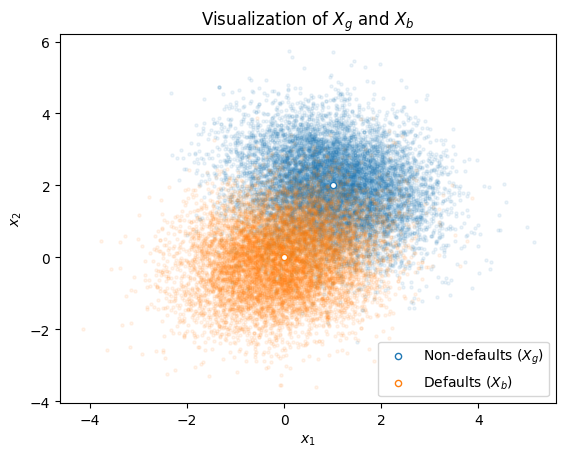

In [4]:
sample_size = 10_000

g_s = data_generator.good_mixture.sample(sample_size).detach().numpy()
b_s = data_generator.bad_mixture.sample(sample_size).detach().numpy()
c_g, c_b = plt.rcParams['axes.prop_cycle'].by_key()['color'][:2]

transparency_alpha = (0.08,)


plt.scatter(g_s[:,0], g_s[:,1], s=5, color=to_rgb(c_g) + transparency_alpha, marker='o')

plt.scatter(b_s[:,0], b_s[:,1], s=5, color=to_rgb(c_b) + transparency_alpha, marker='o')

plt.scatter(data_generator.good_mixture.mean[0].item(), data_generator.good_mixture.mean[1].item(), s=20, color = c_g,
            facecolor='white', edgecolor=c_g,
            label="Non-defaults $\\left(X_g\\right)$")

plt.scatter(data_generator.bad_mixture.mean[0].item(), data_generator.bad_mixture.mean[1].item(), s=20, color = c_b,
            facecolor='white', edgecolor=c_b,
            label="Defaults $\\left(X_b\\right)$")

plt.title("Visualization of $X_g$ and $X_b$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

plt.legend()

plt.show()

This DGP shows that a classification problem, which aims to discriminate
with high confidence (meaning e. g. accept only if PD < $10\%$ - as usual
for an FI) should not be difficult. This also means a simple logit is
of course good enough.

The acceptance loop was done as described by Kozdoi et. al (2025) using
a fixed acceptance rate. Meaning the applicants corresponding to the top
quantile as stated by the acceptance rate were accepted in each generation.
So for an acceptance rate of $20\%$ it means that the applicants having
a predicted PD lower equal than 20th lower percentile would be accepted.
The configuration used for the algorithm was the following:

In [5]:
top_percent = init_objs["configs"]["top_percent"]
sample_size = init_objs["configs"]["sample_size"]
init_sample_size = int(
    acc_based_data.counts_per_round()["total"][0].item()
)
total_gens = acc_based_data.last_gen_round.item() + 1
print("Size of initial sample:", init_sample_size)
print(f"Acceptance Rate: {top_percent:.1%}")
print(f"Applicants per round:", sample_size)
print("Count generation rounds:", total_gens)
print("Applicants accepted per round:", round(sample_size * top_percent))

Size of initial sample: 200
Acceptance Rate: 20.0%
Applicants per round: 100
Count generation rounds: 300
Applicants accepted per round: 20


Now 20 applications accepted per round is too little observations to check the AUC
performance, as the sample size is too little. Also to generate an expectation
based on k-fold validation one needs for the same reasons enough labeled data. Therefore, and considering
that each model was trained (mostly) on the same data in a "small neighborhood of
generations" we can define for a set of generations two "history strides".

First we define the minimal amount of generations needed to make "sensible CV" for
the AUC.

In [6]:
min_gens_passed = 30
history_sample = acc_based_data.to_sample_dataset(up_to_round_idx=min_gens_passed)
print("Count labeled:", history_sample.count_labeled)
print("Count unlabeled:", history_sample.count_unlabeled)

Count labeled: 640
Count unlabeled: 2560


Then we define the "look ahead window" as the amount of generations ahead
of the current history which we would check out to check our hypothesis against.
The window will have as length 5 generations.

In [7]:
look_ahead_window_gens = 5

To get a meaningful feeling about to what we can expect to learn out of
using the differences between expectations and realized performances,
we need to have a benchmark, which would signal how good could we do
with a perfectly functioning RI method. For this we need that the oracle
benchmark and the accepts based classifier have to be assured to be of the
same class.

In [8]:
accepts_based_classif: TorchLogistic = init_objs['classifier_accepts'].to(device)
oracle_classif: TorchLogistic = init_objs['classifier_oracle'].to(device)

assert (
    type(oracle_classif) is type(accepts_based_classif) and
    oracle_classif.lin_estimator.weight.shape == accepts_based_classif.lin_estimator.weight.shape
), "Oracle classifier and Accepts based classifier are not comparable"

Now let's state how we can get a feeling of how the comparisions look like and how they could
look like by showing how the oracle benchmark should look like:

- Accepts based classifier: For each generation from `min_gens_passed` onward, do the following:
    1. Calculate the expectation as K-Fold-Validated AU-ROC metric based on the accepts
       of the available history
    2. Reveal the accepts of the next `look_ahead_window_gens` generations, predict the
       PDs and use them to calculate the realized AU-ROC.
- Oracle classifier: This classifier should tell us, how the difference between the expectation
  and the accepts if somehow the FI could access all true labels of the whole history. The process
  in this case would be divided in two to make it comparable to the accepts based classifier:
    - **Accepted flags generation:** The accepts based classifier calculates both its expectation
      and the realized AU-ROC measures on the accepted population, i. e. the applicants believed
      to have the highest acceptance probabilities at each generation. It is therefore only fair
      to have the evaluation of this metric only over the population belonging to this part of the
      population. The training however would succeed with the complete data-set. In other words
      this is going to be close to have a perfect knowledge of the prior of the rejects and use
      generated pseudo-labels to predict. So the process would looke like this:

        0. For the first generation (`gen_idx=0`) do a CV-K-Fold split. Use the predicted
           probabilites on each validation set as the probability of default one would have predicted
           if this labels would have been "new generations" and the rest would have been the observed
           unbiased history. Doing this split in a sensible way is also trivial as the `bad_ratio` is
           $0.5$
        1. Afterwards for each generation $g$ train the model on the whole unbiased history (so using
           the unbiased observations for $\{0, 1, \ldots, g\}$) and accept the next generation's
           bottom $20\%$ of the applicants based on the according to the probability of default (so
           the best applicants).

    - **Expected and realized AU-ROCs:** Now having the accepted flags we can generate a couple meaningful
      comparisions. Here we keep the logic: cv-evaluate on history from `min_gens_passed` and check realization
      on 
        1. *Unbiased Expectation to unbiased results:* This is the most straightforward. Assuming we have a
           full history or a perfect prior knowledge, how does it differentiate the expectation generated
           by the CV with the current history with the realized AU-ROC of *all* of the future applicants.
        2. *Balanced Expectation over accepts and unbiased to realized accepts:* This should give us two
           expectation to realized AU-ROC comparisions. The first one is naive (expect the accepted of the
           next generation to show a performance like the unbiased history) and the second one is not (use
           unbiasedely estimated classifiers and see their performance on the accepted population). Now
           let's see how the k-folds should be built to be meaningful and how these approaches look like
           
           - <u>Representative K-Folds:</u> consider that per construction and following usual FI 
              behavior, there will always be many more rejects than accepts. Also any functioning 
              classifier would make that this split has important distributional difference between
              the two pools -otherwise RI would be meaningless-. Therefore it would be careless to
              generate the k-folds without making sure that the proportion of accepts to rejects in *each*
              fold is roughly the same. 
              This can also be trivially achieved: Generate the k-folds separetely for the accepts and
              for the rejects, each fold would be the concatenation of each respective fold. $\rightarrow$ 
              Concatenating along the observations axis, which is not a sin against the random selection
              or a way to try to hack the sampling purpose, since which observation comes in which fold
              for both pools is fully random. 

           - <u>Naive Expectation building:</u> expect future accepts to work like the unbiased sample.
              This would be just concatenating both pools of accepts and rejects to then do usual k-fold
              evaluation of the AU-ROC. In principle an expectation building like in the first point, 
              just training over folds explicitly considering the imbalancing between accepts and rejects.
              Therefore the difference in the expectations should be negligible.
           
           - <u>Realistic expectation building:</u> expect an unbiased classifier to work on the future
              accepts as it works on the already seen accepts. As always the each fold is seen as a
              validation set which tries to mimic or simulate how a new generation would look like. So
              we would train over the other folds and evaluate *on the accepts* of the validation fold.
              This might sound like a waste of data - but it mimics exactly what happens when checking
              out the performance on the new generation, since we cannot check how the classifier
              performed over the rejects.

           - <u>Realized AU-ROC:</u> Train over the complete unbiased history and evaluate on the future
             accepts to get the realization of the AUC.

    Note that the accepted flags generation and the expectations cannot occur at the same time in a
    straightforward manner, since for each last generation in the available history, 
    `look_ahead_window_gens` generations have to have become the labeling. However through some clever
    index shifting we can use a single loop for all expectations and acceptances, given that
    the initial accepted flags were already set for the oracle case.

Let's begin by getting a `CreditData` instance with the same information as the simulated `CreditData`
but with different acceptance flags. The cleanest way to keep these separated is just feeding again
a `CreditData` instance with the same realizations as the original one - differentiated only by how
the accepted flags were generated. Of course we need to begin with the first generation, which is
arguably the hardest.

In [9]:
from berebasl.evaluation.k_fold_validation import (
    k_fold_cv_normalized_split,
    train_predict_classifier_fold
)
k_folds = 5
min_bads = 4
## Get the unbiased observations of the first generation
init_feats, init_lbls = acc_based_data.unbiased_obs(up_to_round_idx=0)
## Split the data
init_feats_cv, init_lbls_cv, mask_init_cv = k_fold_cv_normalized_split(init_feats, init_lbls, k=k_folds, min_bads=min_bads)
## Train and validate cv-style to get labels for each validation fold
init_preds = torch.stack(
        [train_predict_classifier_fold(init_feats_cv, init_lbls_cv, mask_init_cv, oracle_classif, k) 
         for k in range(k_folds)],
        dim=0
    )

## Put back the feats and inits into a 2d representation
init_feats, init_lbls, init_preds = [ten[mask_init_cv] for ten in (init_feats_cv, init_lbls_cv, init_preds)]
accepted_mask = init_preds <= init_preds.quantile(top_percent) # BAD Probs were inferred

oracle_data = CreditData(
    init_feats, init_lbls, accepted_mask
)

After the initial data has been added, a loop evaluating the expectations and
realizations can be built. However, before a filling up of the `oracle_credit_data``
needs to be done to be able to do all listed comparisions.

In [10]:
from berebasl.estimation.classifiers import Classifier


def add_accept_to_oracle_data(
        oracle_credit_data: CreditData,
        oracle_classifier: Classifier,
        full_credit_data: CreditData,
        top_percent: float
) -> None:
    historic_feats, historic_lbls = oracle_credit_data.unbiased_obs()
    oracle_classifier.reset_parameters_to_initial()
    oracle_classifier.fit(historic_feats, historic_lbls)

    next_gen_idx = oracle_credit_data.last_gen_round.item() + 1
    new_feats, new_lbls = full_credit_data.unbiased_obs(from_round_idx=next_gen_idx, up_to_round_idx=next_gen_idx)

    estimated_pd_new_feats = oracle_classifier.predict_proba(new_feats)[..., 1]
    new_accepted_flags = estimated_pd_new_feats <= estimated_pd_new_feats.quantile(top_percent)

    oracle_credit_data.add_gen(new_feats, new_lbls, new_accepted_flags)

### Containers for the loop
hist_steps_to_check_out = total_gens-look_ahead_window_gens - min_gens_passed

au_rocs = {}
categories_auc = ["acc_based", "oracle_naive", "oracle_comparable"]
real_lbls = ['acc_biased', 'acc_unbiased', 'all']
exp_lbl = "exp"
for category_auc in categories_auc:
    for exp_real in [exp_lbl] + real_lbls:
        size = torch.Size([hist_steps_to_check_out])
        if exp_real == "exp":
            size += torch.Size([k_folds])

        key = category_auc + '_' + exp_real
        au_rocs[key] = acc_based_data.features.new_full(size, fill_value=-1)

In [11]:
from berebasl.evaluation.batched_metrics import batched_auroc
from berebasl.evaluation.k_fold_validation import k_fold_evaluate_classifier_on_metric
from typing import Any, Callable, Dict, Union, Tuple
def realized_performance(
        hist_feats: torch.Tensor,
        hist_lbls: torch.Tensor,
        future_feats: torch.Tensor,
        future_lbls: torch.Tensor,
        classif: Classifier,
        metric: Callable[[torch.Tensor, torch.Tensor], Union[float, torch.Tensor]],
        further_metric_kwargs : Dict[str, Any] = {}
) -> Union[torch.Tensor, float]:
    classif.reset_parameters_to_initial()
    classif.fit(hist_feats, hist_lbls)
    if callable(getattr(classif, "eval", None)):
        classif.eval()

    with torch.no_grad():
        preds_bad = classif.predict_proba(future_feats)[..., 1]
        return metric(preds_bad, future_lbls, **further_metric_kwargs)
    
def exp_and_real_perf_on_labeled(
        hist_feats: torch.Tensor,
        hist_lbls: torch.Tensor,
        rng: torch.Generator,
        k_folds: int,
        min_bads: int,
        classif: Classifier,
        future_feats: torch.Tensor,
        future_lbls: torch.Tensor,
        batched_metric: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
        metrics_mask_name: str = "mask_valid",
        further_metric_kwargs: Dict[str, Any] = {}
) -> Tuple[torch.Tensor, torch.Tensor]:
    labeled_based_exp = k_fold_evaluate_classifier_on_metric(
        feats=hist_feats,
        labels=hist_lbls,
        rng=rng,
        k_folds=k_folds,
        min_bads=min_bads,
        classif=classif,
        batched_metric=batched_metric,
        metrics_mask_name=metrics_mask_name,
        further_metric_kwargs=further_metric_kwargs
    )
    realized = realized_performance(
        hist_feats=hist_feats,
        hist_lbls=hist_feats,
        future_feats=future_feats,
        future_lbls=future_lbls,
        classif=classif,
        metric=batched_metric,
        further_metric_kwargs=further_metric_kwargs
    )

    return labeled_based_exp, realized

In [12]:
def time_split_data(
        acc_based_data: CreditData,
        oracle_data: CreditData,
        consider_history_up_to: int,
        look_ahead_window_gens: int
) -> Tuple[Tuple[Dict[str,torch.Tensor]]]:
    # 1. Gather data
    ## Historic
    ### Biased
    hist_sample = acc_based_data.to_sample_dataset(up_to_round_idx=consider_history_up_to)
    ### Unbiased
    hist_feats_unb, hist_lbls_unb, was_acc_mask_oracle = oracle_data.unbiased_obs(
        include_accepted_status=True,
        up_to_round_idx=consider_history_up_to
    )
    ### Rejects according to oracle among unbiased
    was_rej_mask_oracle = ~was_acc_mask_oracle
    hist_oracle_rej_feats = hist_feats_unb[was_rej_mask_oracle]
    hist_oracle_rej_lbls = hist_lbls_unb[was_rej_mask_oracle]
    ### Accepts according to oracle among unbiased
    hist_oracle_acc_feats = hist_feats_unb[was_acc_mask_oracle]
    hist_oracle_acc_lbls = hist_lbls_unb[was_acc_mask_oracle]
    ## Future
    ### Biased, acc_classif
    future_sample_acc_based = acc_based_data.to_sample_dataset(
        from_round_idx=consider_history_up_to+1, 
        up_to_round_idx=consider_history_up_to+look_ahead_window_gens
    )
    ### Biased, oracle
    future_sample_oracle = oracle_data.to_sample_dataset(
        from_round_idx=consider_history_up_to+1, 
        up_to_round_idx=consider_history_up_to+look_ahead_window_gens
    )
    ### Unbiased
    future_feats_unb, future_lbls_unb = acc_based_data.unbiased_obs( # Same as in oracle
        from_round_idx=consider_history_up_to+1, 
        up_to_round_idx=consider_history_up_to+look_ahead_window_gens
    )

    # 2. Create dictionaries for clean
    hist_feats = {
        "acc_based" : hist_sample.features_labeled,
        "oracle_naive" : hist_feats_unb,
        "oracle_comparable" : {
            "feats_rej" : hist_oracle_rej_feats,
            "feats_acc" : hist_oracle_acc_feats
        }
    }
    hist_lbls = {
        "acc_based" : hist_sample.labels,
        "oracle_naive" : hist_lbls_unb,
        "oracle_comparable" : {
            "lbls_rej" : hist_oracle_rej_lbls,
            "lbls_acc" : hist_oracle_acc_lbls
        }
    }

    future_feats = {
        "acc_biased" : future_sample_acc_based.features_labeled,
        "acc_unbiased" : future_sample_oracle.features_labeled,
        "all" : future_feats_unb
    }
    future_lbls = {
        "acc_biased" : future_sample_acc_based.labels,
        "acc_unbiased" : future_sample_oracle.labels,
        "all" : future_lbls_unb
    }

    return (hist_feats, hist_lbls), (future_feats, future_lbls)

In [14]:
def realistic_oracle_exp(
        feats_rej: torch.Tensor,
        feats_acc: torch.Tensor,
        lbls_rej: torch.Tensor,
        lbls_acc: torch.Tensor,
        rng: torch.Generator,
        k_folds: int,
        min_bads: int,
        classif: Classifier,
        batched_metric : callable,
        metrics_mask_name: str = "mask_valid",
        further_metrics_kwargs: dict = {}
) -> torch.Tensor:
    # This function manages only partly batched input
    feats_acc_cv, lbls_acc_cv, mask_valid_acc_cv = k_fold_cv_normalized_split(
        feats_acc,
        lbls_acc,
        rng=rng,
        k=k_folds,
        min_bads=min_bads
    )
    feats_rej_cv, lbls_rej_cv, mask_valid_rej_cv = k_fold_cv_normalized_split(
        feats_rej,
        lbls_rej,
        rng=rng,
        k=k_folds,
        min_bads=min_bads
    )

    preds_cv = []

    for k_vali in range(k_folds):
        mask_train_acc = mask_valid_acc_cv.clone() # [*super_batch_dims, k_folds, fold_rows]
        mask_train_acc[..., k_vali, :] &= False
        mask_train_rej = mask_valid_rej_cv.clone()
        mask_train_rej[..., k_vali, :] &= False

        feats_train = torch.cat([
            feats_rej_cv[mask_train_rej],
            feats_acc_cv[mask_train_acc]
        ], dim=0) # [N_train, F]
        lbls_train = torch.cat([
            lbls_rej_cv[mask_train_rej],
            lbls_acc_cv[mask_train_acc]
        ], dim=0) # [N_train]

        classif.reset_parameters_to_initial()
        classif.fit(feats_train, lbls_train)

        feats_val = feats_acc_cv[~mask_train_acc]
        with torch.no_grad():
            preds_cv.append(
                classif.predict_proba(feats_val)[..., -1]
            )

    preds_cv = torch.stack(preds_cv, dim=0)

    return batched_metric(preds_cv, lbls_acc_cv, **{metrics_mask_name : mask_valid_acc_cv}, **further_metrics_kwargs)



In [ ]:
from berebasl.evaluation.batched_metrics import batched_auroc
from berebasl.evaluation.k_fold_validation import k_fold_evaluate_classifier_on_metric
generator_loop = range(
    -look_ahead_window_gens + 1, # Begin before to be filling up the needed accepts, considering accepts for gen 0 are filled
    total_gens-look_ahead_window_gens # Need to have enough after
)
rng = torch.Generator(device)
for shifted_idx in generator_loop:
    add_accept_to_oracle_data(oracle_data, oracle_classif, acc_based_data, top_percent)
    if shifted_idx < min_gens_passed:
        continue

    if (shifted_idx+1) % 30 == 0:
        print("Starting checking history up to", shifted_idx, "/", total_gens-look_ahead_window_gens)

    consider_history_up_to = shifted_idx
    idx_au_rocs = consider_history_up_to - min_gens_passed

    (hist_feats, hist_lbls), (future_feats, future_lbls) = time_split_data(
        acc_based_data=acc_based_data,
        oracle_data=oracle_data,
        consider_history_up_to=consider_history_up_to,
        look_ahead_window_gens=look_ahead_window_gens
    )

    classifiers_to_check = zip(["acc_based", "oracle_naive", "oracle_comparable"],
                               [accepts_based_classif, oracle_classif, oracle_classif])

    for classif_lbl, classifier in classifiers_to_check:
        if classif_lbl != "oracle_comparable":
            au_rocs[f"{classif_lbl}_exp"][idx_au_rocs] = k_fold_evaluate_classifier_on_metric(
                feats=hist_feats[classif_lbl],
                labels=hist_lbls[classif_lbl],
                rng=rng,
                k_folds=k_folds,
                min_bads=min_bads,
                classif=classifier,
                batched_metric=batched_auroc
            )
        else:
            au_rocs[f"{classif_lbl}_exp"][idx_au_rocs] = realistic_oracle_exp(
                **hist_feats[classif_lbl], **hist_lbls[classif_lbl],
                rng=rng,
                k_folds=k_folds,
                min_bads=min_bads,
                classif=classifier,
                batched_metric=batched_auroc
            )

        for realization_type in real_lbls:
            classif_lbl_realtype = "oracle_naive" if classif_lbl == "oracle_comparable" else classif_lbl
            perf = realized_performance(
                hist_feats=hist_feats[classif_lbl_realtype],
                hist_lbls=hist_lbls[classif_lbl_realtype],
                future_feats=future_feats[realization_type],
                future_lbls=future_lbls[realization_type],
                classif=classifier,
                metric=batched_auroc
            )
            au_rocs[f"{classif_lbl}_{realization_type}"][idx_au_rocs] = perf

c:\Users\mateo\Documents\Universidad\Master\Thesis\BEReBASL\berebasl\evaluation\k_fold_validation.py:103: UserWarning: There are not enough bads in the data to achieve 4 in each fold
  warn(f"There are not enough bads in the data to achieve {min_bads} in each fold")


Starting checking history up to 59 / 295
Starting checking history up to 89 / 295
Starting checking history up to 119 / 295
Starting checking history up to 149 / 295
Starting checking history up to 179 / 295
Starting checking history up to 209 / 295
Starting checking history up to 239 / 295
Starting checking history up to 269 / 295


Order for a nice plotting, so that one can see the span of the expecations there

In [16]:
for cat in categories_auc:
    au_rocs[cat + '_exp'] = au_rocs[cat + '_exp'].sort(dim=-1).values

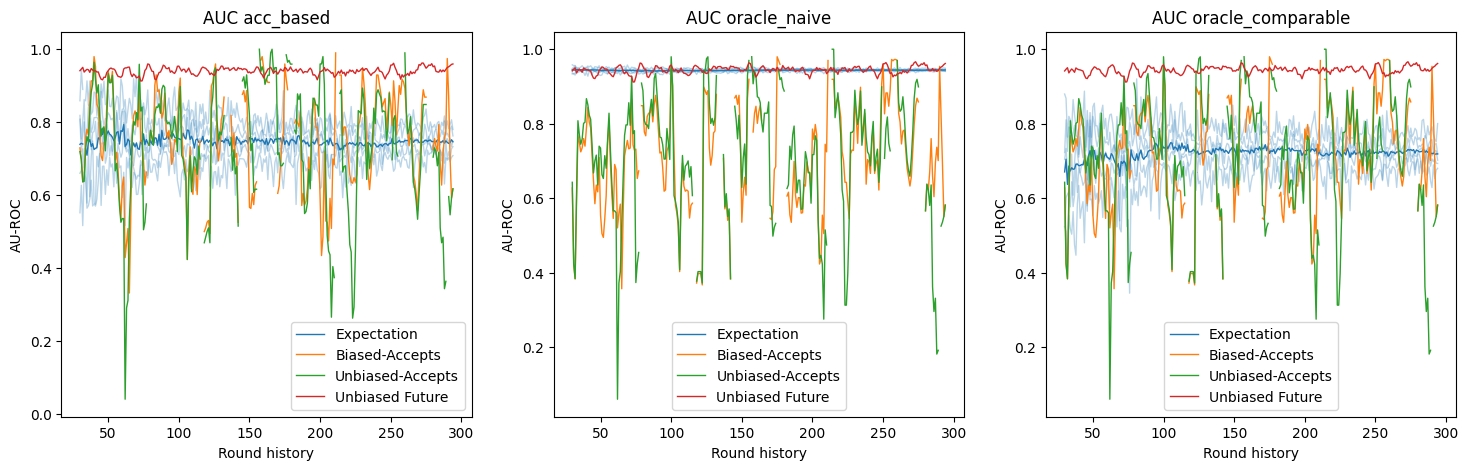

In [24]:
import matplotlib.colors as mcolors
hist_up_to_idx = torch.arange(min_gens_passed, total_gens-look_ahead_window_gens, device=torch.device('cpu')).numpy()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors_dict = {lbl : c for c, lbl in zip(colors[:len(real_lbls) + 1], [exp_lbl] + real_lbls)}
report_real_lbls = {
    "acc_biased" : "Biased-Accepts",
    "acc_unbiased" : "Unbiased-Accepts",
    "all" : "Unbiased Future"
}

fig, axes = plt.subplots(ncols=3, figsize=(18,5))


for cat, ax in zip(categories_auc, axes):
    ax.plot(hist_up_to_idx, au_rocs[cat + "_exp"].mean(dim=-1).detach().cpu().numpy(),
            c=colors_dict["exp"], lw=1, label="Expectation")
    
    for k in range(k_folds):
        ax.plot(hist_up_to_idx,au_rocs[cat + "_exp"][:,k].detach().cpu().numpy(),
                c = mcolors.to_rgb(colors_dict["exp"]) + (0.3,), lw=1)
        
    for r in real_lbls:
        ax.plot(hist_up_to_idx, au_rocs[cat+'_' + r].detach().cpu().numpy(),
                c = colors_dict[r], lw=1, label = report_real_lbls[r])
        
    ax.set_title("AUC " + cat)
    ax.set_ylabel("AU-ROC")
    ax.set_xlabel("Round history")
    ax.legend()


## From disapointment to a reward for RL training

In principle for any moment measuring the expected and the realized performance
of a model is not hard. However the question is how to use this information.
Using RL we can in principle define a reward to minimize the distance between
the realized performance and the expected performance. Again for an on policy
learning algorithm this would not be hard, however given that in reality
financial data is expensive and scarce, we need to think in some off-policy
mechanism that can use data more efficiently. Also this calculations are
likely expensive, therefore it would be a good idea to use a Replay buffer as
well.

All of these mechanisms together require a way to train efficiently and
handle efficiently batches of samples. Since at each "generation step"
the data gets larger and larger, we get the problem, that we need to work
with masking as well - making the engineering behind it the more difficult.